In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
import qkd_sf as qsf
from importlib import reload
import plotly.graph_objects as go

In [28]:
import plotly.io as pio

pio.renderers.default = "notebook"

In [2]:
def reload_protocols():
    reload(qsf)

## Parameters for RR

In [149]:
eta = 0.1
keylen = 1
sigma_grid = np.linspace(0.001, 10, 31)
var_a_grid = sigma_grid**2
V_grid = np.linspace(0.1, 1,51)

### Mutual Information

In [150]:
reload_protocols()
I_grid_x_RR = np.zeros((len(var_a_grid), len(V_grid)))
for i,v in enumerate(V_grid):
    I_RR, I_x_RR, I_p_RR = qsf.MC_I_AB(var_a_grid, eta, keylen, v)
    I_grid_x_RR[:,i] = I_x_RR
    print(f"\rProgress: {i+1}/{len(V_grid)}", end="", flush=True)

Progress: 7/51

c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply


Progress: 51/51

In [151]:
reload_protocols()
th_I_grid_x_RR = np.zeros((len(var_a_grid), len(V_grid)))
for i,v in enumerate(V_grid):
    th_I_RR, th_I_x_RR, th_I_p_RR = qsf.theoretical_I_AB(var_a_grid, eta, v)
    th_I_grid_x_RR[:,i] = th_I_x_RR

### Holevo Bound

In [152]:
reload_protocols()
th_chi_x_grid_RR = np.zeros((len(var_a_grid), len(V_grid)))
for i,var_a in enumerate(var_a_grid):
    for j,v in enumerate(V_grid):
        
        th_chi_x_grid_RR[i][j] = qsf.holevo_RR_SF(eta, var_a, v, 'x')
    print(f"\rProgress: {i+1}/{len(var_a_grid)}", end="", flush=True)

Progress: 31/31

### 3D Plots

In [153]:
b=0.9
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)
#fig.add_trace(go.Scatter3d(x=V_mesh.ravel(), y=var_a_mesh.ravel(), z=I_grid_x_RR.ravel(), mode='markers', marker=dict(size=3, color='blue')))
fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_I_grid_x_RR, surfacecolor=np.zeros_like(th_I_grid_x_RR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_chi_x_grid_RR, surfacecolor=np.zeros_like(th_chi_x_grid_RR), colorscale=[[0.0, 'red'], [1.0, 'red']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title=r"var_a", zaxis = dict(title="Info"), aspectmode ="cube"), width=900, height=750)

fig.show()
        

In [154]:
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=b*th_I_grid_x_RR-th_chi_x_grid_RR, surfacecolor=np.zeros_like(b*th_I_grid_x_RR-th_chi_x_grid_RR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title="var_a", zaxis = dict(title="Info", range=[0, None]), aspectmode ="cube"), width=900, height=750)
fig.show()
        

### Plot Mutual Information & Holevo Bound

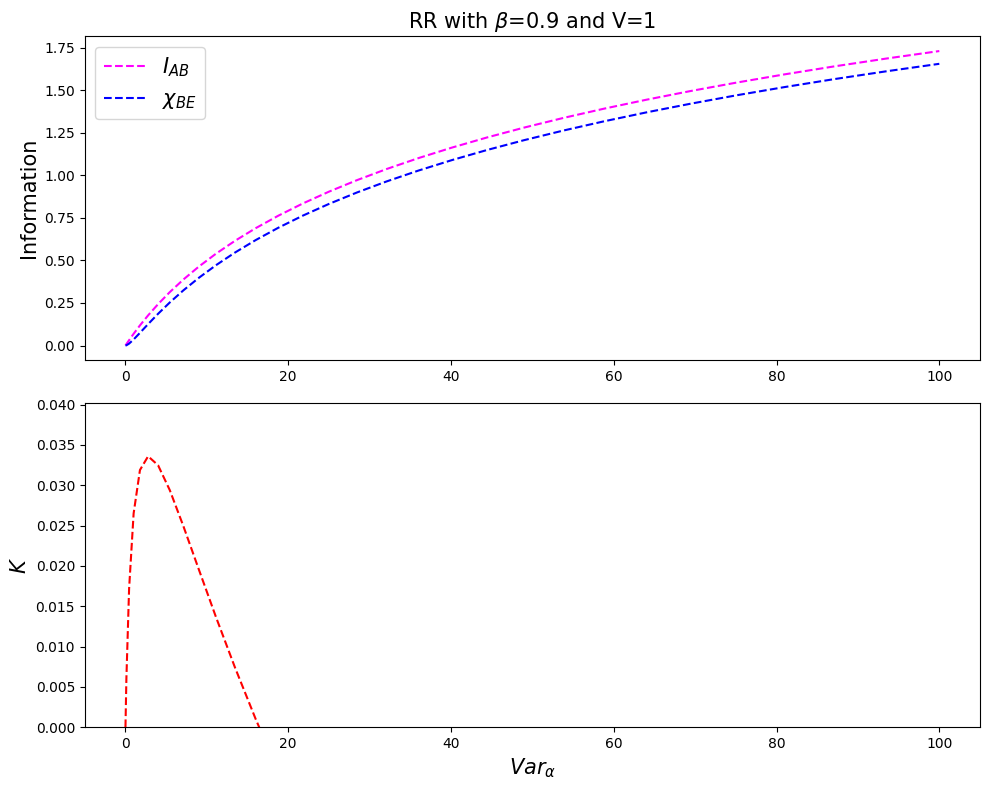

In [155]:
reload_protocols()

V=1
b = 0.9
idx = np.where(V_grid==V)[0][0]
th_I_x_RR = (th_I_grid_x_RR[:, idx])
th_chi_x_RR = (th_chi_x_grid_RR[:, idx])


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), dpi=100)

ax[0].set_title(rf'RR with $\beta$={b} and V={V}', fontsize=15)
ax[0].scatter(var_a_grid, I_x_RR, s=15, color = 'magenta')
ax[0].plot(var_a_grid, th_I_x_RR, '--', color='magenta', label=r'$I_{AB}$')
ax[0].plot(var_a_grid, th_chi_x_RR, 'b--', label=r'$\chi_{BE}$')
ax[0].set_ylabel(r'Information', fontsize=15)
ax[0].legend(fontsize=15)

ax[1].plot(var_a_grid, qsf.key_rate(b,  th_I_x_RR, th_chi_x_RR), '--r', label = f'Key-Rate')
ax[1].scatter(var_a_grid, qsf.key_rate(b, I_x_RR, th_chi_x_RR), s=15, color = 'red', label = f'MC Key-Rate')
ax[1].set_xlabel(r'$Var_{{\alpha}}$', fontsize=15)
ax[1].set_ylim(0)
ax[1].set_ylabel(r'$K$', fontsize=15)
plt.tight_layout()



## Parameters for DR protocol

In [156]:
eta = 0.6
keylen = 1
sigma_grid = np.linspace(0.001,10, 51)
var_a_grid = sigma_grid**2
V_grid = np.linspace(0.1, 1, 31)

### Mutual Information

In [157]:
reload_protocols()
I_grid_x_DR = np.zeros((len(var_a_grid), len(V_grid)))
for i,v in enumerate(V_grid):
    I_DR, I_x_DR, I_p_DR = qsf.MC_I_AB(var_a_grid, eta, keylen, v)
    I_grid_x_DR[:, i] = I_x_DR
    print(f"\rProgress: {i+1}/{len(V_grid)}", end="", flush=True)

Progress: 31/31

In [158]:
reload_protocols()
th_I_grid_x_DR = np.zeros((len(var_a_grid), len(V_grid)))
for i,v in enumerate(V_grid):
    th_I_DR, th_I_x_DR, th_I_p_DR = qsf.theoretical_I_AB(var_a_grid, eta, v)
    th_I_grid_x_DR[:, i] = th_I_x_DR

### Holevo Bound

In [159]:
reload_protocols()
th_chi_x_grid_DR = np.zeros((len(var_a_grid), len(V_grid)))
for i,var_a in enumerate(var_a_grid):
    for j,v in enumerate(V_grid):
        
        th_chi_x_grid_DR[i][j] = qsf.holevo_DR_SF(eta, var_a, v, 'x')
    print(f"\rProgress: {i+1}/{len(var_a_grid)}", end="", flush=True)

Progress: 51/51

### 3D Plots

In [161]:
b=0.9
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)
#fig.add_trace(go.Scatter3d(x=V_mesh.ravel(), y=var_a_mesh.ravel(), z=I_grid_x_DR.ravel(), mode='markers', marker=dict(size=3, color='blue')))
fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_I_grid_x_DR, surfacecolor=np.zeros_like(th_I_grid_x_DR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=th_chi_x_grid_DR, surfacecolor=np.zeros_like(th_chi_x_grid_DR), colorscale=[[0.0, 'red'], [1.0, 'red']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title="var_a", zaxis = dict(title="Info"), aspectmode ="cube"), width=900, height=750)

fig.show()

In [162]:
fig = go.Figure()

var_a_mesh, V_mesh = np.meshgrid(var_a_grid, V_grid)

fig.add_trace(go.Surface(x=V_grid, y=var_a_grid, z=b*th_I_grid_x_DR-th_chi_x_grid_DR, surfacecolor=np.zeros_like(b*th_I_grid_x_DR-th_chi_x_grid_DR), colorscale=[[0.0, 'magenta'], [1.0, 'blue']], showscale=False))

fig.update_layout(scene=dict(xaxis_title="V", yaxis_title="var_a", zaxis = dict(title="Info", range=[0, None]), aspectmode ="cube"), width=900, height=750)
fig.show()

### Plot Mutual Information & Holevo Bound

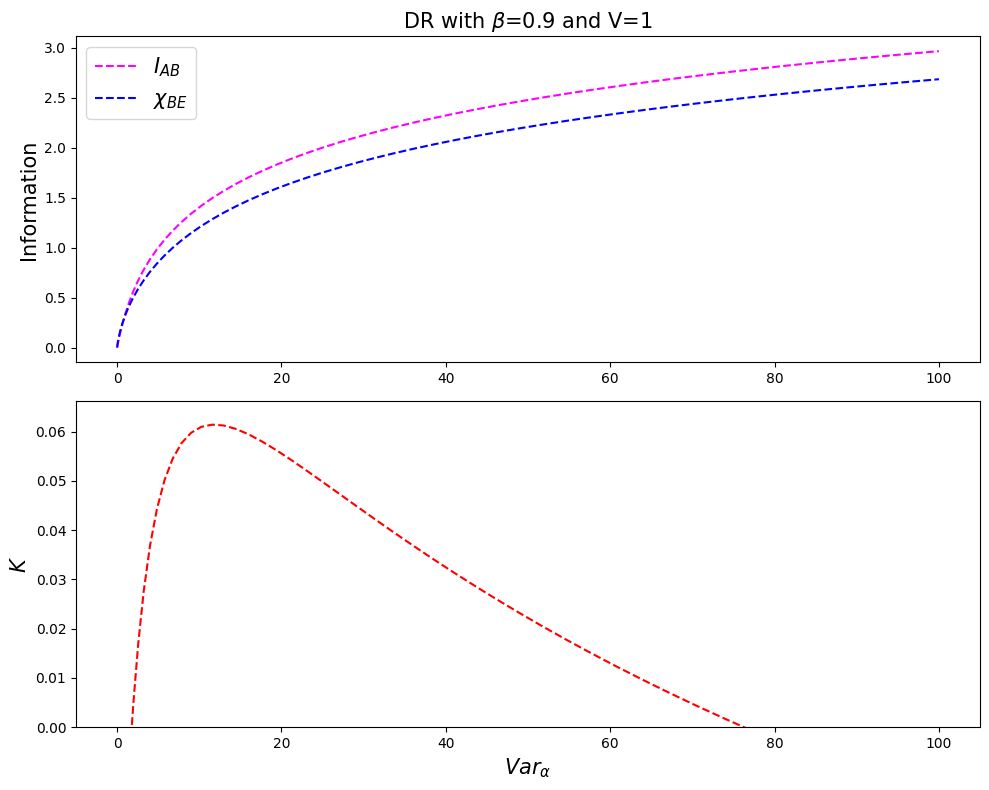

In [163]:
reload_protocols()

V=1
b = 0.9
idx = np.where(V_grid==V)[0][0]
th_I_x_DR = (th_I_grid_x_DR[:, idx])
th_chi_x_DR = (th_chi_x_grid_DR[:, idx])

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), dpi=100)

ax[0].set_title(rf'DR with $\beta$={b} and V={V}', fontsize=15)
ax[0].scatter(var_a_grid, I_x_DR, s=15, color = 'magenta')
ax[0].plot(var_a_grid, th_I_x_DR, '--', color='magenta', label=r'$I_{AB}$')
ax[0].plot(var_a_grid, th_chi_x_DR, 'b--', label=r'$\chi_{BE}$')
ax[0].set_ylabel(r'Information', fontsize=15)
ax[0].legend(fontsize=15)

ax[1].plot(var_a_grid, qsf.key_rate(b,  th_I_x_DR, th_chi_x_DR), '--r', label = f'Key-Rate')
ax[1].scatter(var_a_grid, qsf.key_rate(b, I_x_DR, th_chi_x_DR), s=15, color = 'red', label = f'MC Key-Rate')
ax[1].set_xlabel(r'$Var_{{\alpha}}$', fontsize=15)
ax[1].set_ylim(0)
ax[1].set_ylabel(r'$K$', fontsize=15)
plt.tight_layout()

